Ashbah Faisal
af08271@st.habib.edu.pk
Homework Assignment 2: Exploratory Data Analysis (EDA)


In [9]:
#part1
import pandas as pd

# Loading the data
df = pd.read_csv('C:\\Users\\cw\\Desktop\\FIFA_Players_Data.csv')

# no of missing values in each row
df1 = df.isnull().sum()
#df1
# Dropping column with no values
df = df.drop(columns=['release_clause_eur'])

# Impute or replace missing values
# Use mode to fill missing values in categorical columns 
df['team_position'] = df['team_position'].fillna(df['team_position'].mode()[0])
df['nation_position'] = df['nation_position'].fillna(df['nation_position'].mode()[0])
df['contract_valid_until'] = df['contract_valid_until'].fillna(df['contract_valid_until'].mode()[0])

#Use mean to fill missing values in numerical columns 
df['pace'] = df['pace'].fillna(df['pace'].mean())
df['shooting'] = df['shooting'].fillna(df['shooting'].mean())
df['passing'] = df['passing'].fillna(df['passing'].mean())
df['dribbling'] = df['dribbling'].fillna(df['dribbling'].mean())
df['defending'] = df['defending'].fillna(df['defending'].mean())
df['physic'] = df['physic'].fillna(df['physic'].mean())

# Use median to fill missing values in ordinal numerical columns 
df['team_jersey_number'] = df['team_jersey_number'].fillna(df['team_jersey_number'].median())
df['nation_jersey_number'] = df['nation_jersey_number'].fillna(df['nation_jersey_number'].median())

#  Using the most common year as a filler
df['joined'] = df['joined'].fillna(df['joined'].mode()[0])

# Drop rows where nation_position is GK
df= df[df['nation_position'] != 'GK']

# Check the result for missing values after imputation
df1 = df.isnull().sum()
#print(df1)
#here all coloums are printed along with 0 indicating no row is empty
#fuction to replave + or - with value after performing the operation
def process_skill_value(value):
    # value check if it contains a '+' or '-'
    if isinstance(value, str) and ('+' in value or '-' in value):
        if '+' in value:
            base, increment = value.split('+')
            return int(base) + int(increment)
        elif '-' in value:
            base, decrement = value.split('-')
            return int(base) - int(decrement)
    return int(value)

# onvert these cols to integers
df['skill_ball_control'] = df['skill_ball_control'].apply(process_skill_value).astype(int)
df['power_stamina'] = df['power_stamina'].apply(process_skill_value).astype(int)
df


#Save the cleaned DataFrame to a new CSV file
df.to_csv('C:/Users/cw/Desktop/Cleaned_FIFA_Players_Data.csv', index=False)


### at fisrt i have printed the number of missing values in each coloumn to check which coloumn needs to be cleanedthan i have dropped the coloumn which has no value then i have used mode for categorical values, mean for numerical values and Unknown for missing dates in joined further on i have dropped rows from nation_position which contained GK than i have printed the number of missing values in each coloumn which came out to be 0 for all explaining that my work has filled all the coloumns. Than i have constructed a functions where if a value contains a + or a - than split the value and add or subtract accordingly.This how the data has been cleaned.

In [59]:
#Part 2.1
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data = pd.read_csv('C:/Users/cw/Desktop/Cleaned_FIFA_Players_Data.csv')


# Mean 
mean_overall_by_club = data.groupby('club')['overall'].mean().reset_index().sort_values(by='overall', ascending=False)

# Median 
median_age_by_nationality = data.groupby('nationality')['age'].median().reset_index().rename(columns={'age': 'median_age'})

# Mode
mode_foot_by_nationality = data.groupby('nationality')['preferred_foot'].agg(lambda x: x.mode()[0]).reset_index()

# Count 
nationality_count = data.groupby('nationality').size().reset_index(name='player_count').sort_values(by='player_count', ascending=False)


mean_overall_by_club,median_age_by_nationality,mode_foot_by_nationality,nationality_count




(                       club    overall
 195            FC Barcelona  79.608696
 198       FC Bayern München  78.178571
 369             Netherlands  78.000000
 401     Paris Saint-Germain  77.666667
 420                Portugal  77.333333
 ..                      ...        ...
 172         Drogheda United  52.000000
 155  Dagenham and Redbridge  52.000000
 80           Bray Wanderers  51.640000
 48             Athlone Town  51.520000
 548                 UCD AFC  51.520000
 
 [596 rows x 2 columns],
            nationality  median_age
 0              Albania        24.0
 1              Algeria        25.0
 2               Angola        24.5
 3    Antigua & Barbuda        21.0
 4            Argentina        25.0
 ..                 ...         ...
 143         Uzbekistan        27.0
 144          Venezuela        26.0
 145              Wales        23.0
 146             Zambia        23.0
 147           Zimbabwe        25.0
 
 [148 rows x 2 columns],
            nationality preferred_

### This code analyses data statistics, calculating mean ratings, median ages, mode of preferred foot, and player counts, using group by functions. The methods used above are good to provide summary to an anlysist working on large nmber of data.

###

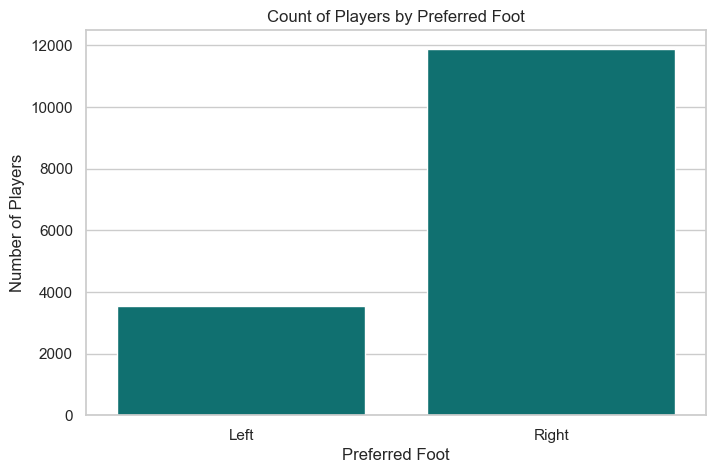

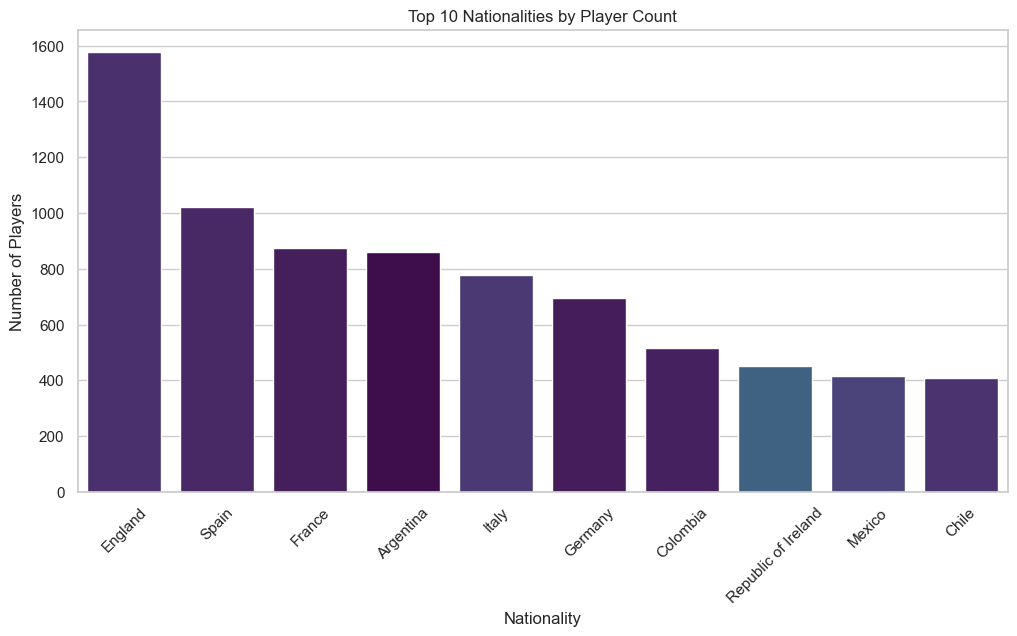

C:\Users\cw\AppData\Local\Temp\ipykernel_7028\387484067.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=work_rate_counts.index, y=work_rate_counts.values, palette='viridis')


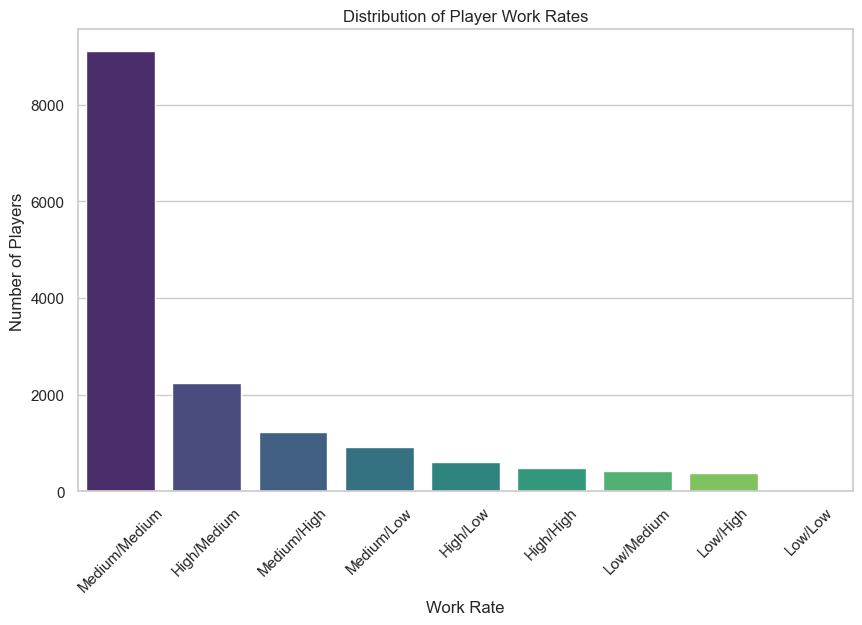

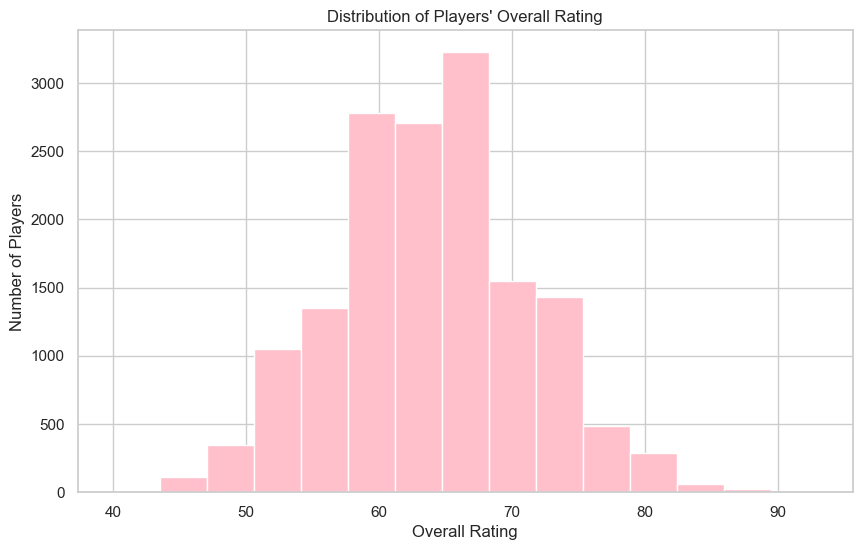

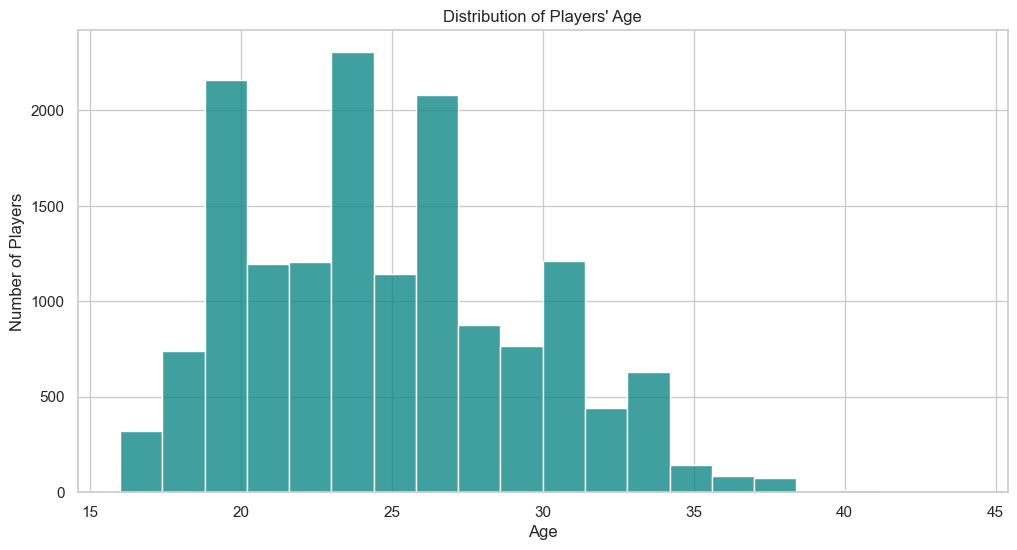

In [114]:
#part 2.2
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


data = pd.read_csv('C:/Users/cw/Desktop/Cleaned_FIFA_Players_Data.csv')

# Univariate Analysis
# Bar graph
# 1 Count of Players by Preferred Foot
plt.figure(figsize=(8, 5))
sns.countplot(x='preferred_foot', data=data, color='teal') #to use a single color palette was giving error
plt.title('Count of Players by Preferred Foot')
plt.xlabel('Preferred Foot')
plt.ylabel('Number of Players')
plt.xticks(rotation=0)
plt.show()

#2 Top 10 Nationalities by Player Count
plt.figure(figsize=(12, 6))
ax = sns.countplot(x='nationality', data=data, order=data['nationality'].value_counts()[:10].index, hue='nationality', palette='viridis', legend=False)
ax.set_title('Top 10 Nationalities by Player Count')
ax.set_xlabel('Nationality')
ax.set_ylabel('Number of Players')
ax.tick_params(axis='x', rotation=45)
plt.show()

# 3 Distribution of Player Work Rates
plt.figure(figsize=(10, 6))
work_rate_counts = data['work_rate'].value_counts()
sns.barplot(x=work_rate_counts.index, y=work_rate_counts.values, palette='viridis')
plt.title('Distribution of Player Work Rates')
plt.xlabel('Work Rate')
plt.ylabel('Number of Players')
plt.xticks(rotation=45)
plt.show()

# Histogram 
#1 Distribution of Players against Overall Rating
plt.figure(figsize=(10, 6))
plt.hist(data['overall'], bins=15, color='pink')
plt.title('Distribution of Players\' Overall Rating')
plt.xlabel('Overall Rating')
plt.ylabel('Number of Players')
plt.grid(True)
plt.show

#2 Distribution of Players against Age
plt.figure(figsize=(12, 6))
ax = sns.histplot(data['age'], bins=20, kde=False, color='teal')
ax.set_title('Distribution of Players\' Age')
ax.set_xlabel('Age')
ax.set_ylabel('Number of Players')
plt.show()


### The first Univariate bar graph explains how around 12000 players prefer to use the right foot compared to 4000 other players who prefer to use the left foot.
### the second bargraph displays taht most players are from england which is around 16000 while least amount of players are from chille
### in the third bargraph a comparison has been drawn between the workload for various players it states that there are around 9000 number of players who have statedb their workload to be Medium/Medium and hardly any player has stated Low/High workload.
### the 4th graph i.e histogram displays that around 3500 players rating is around 70 and the least amount of players have around 90 rating.
### in the last histogram most players age is around 25 while there are hardly any players who are 35+.



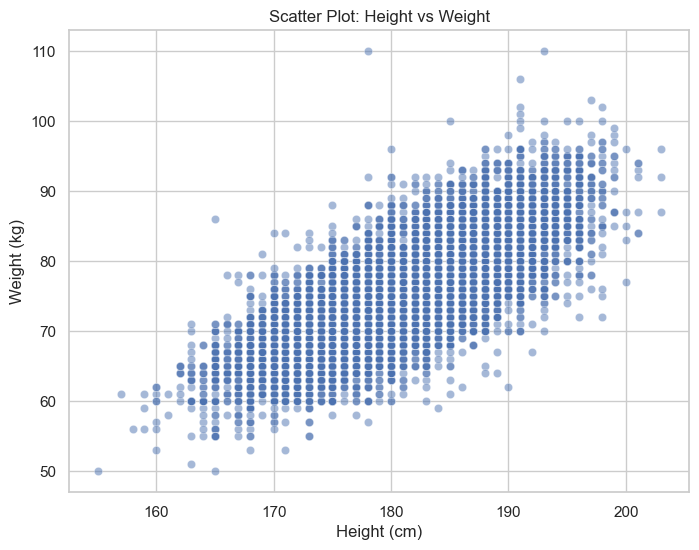

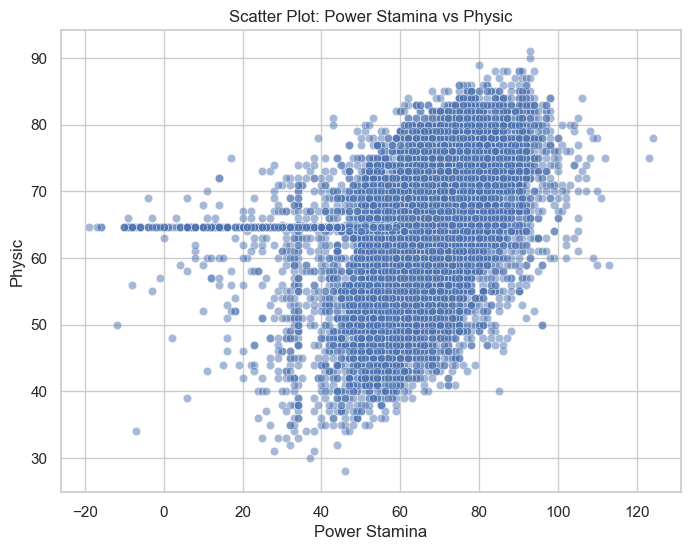

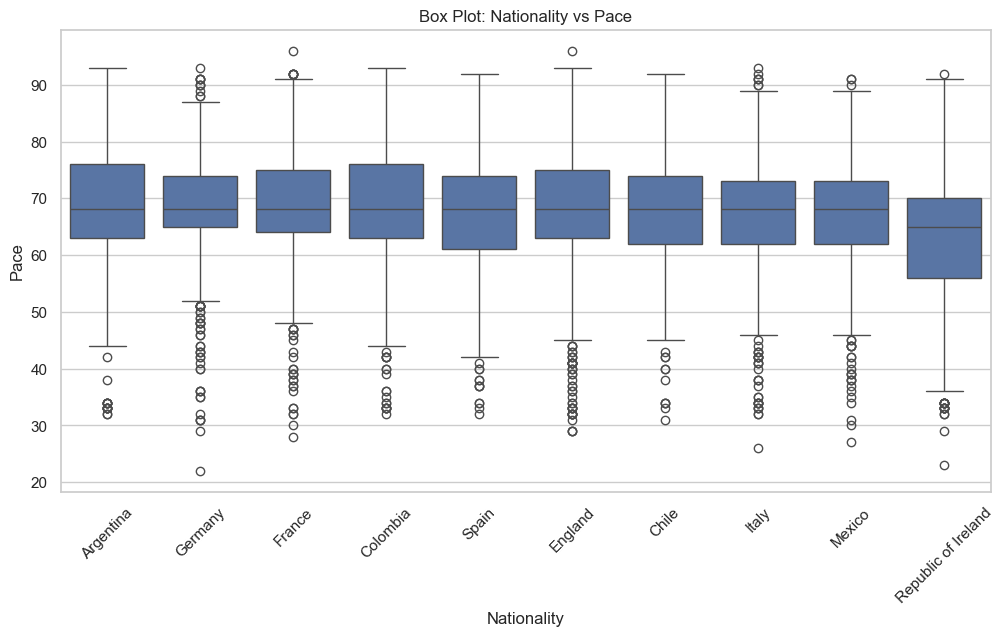

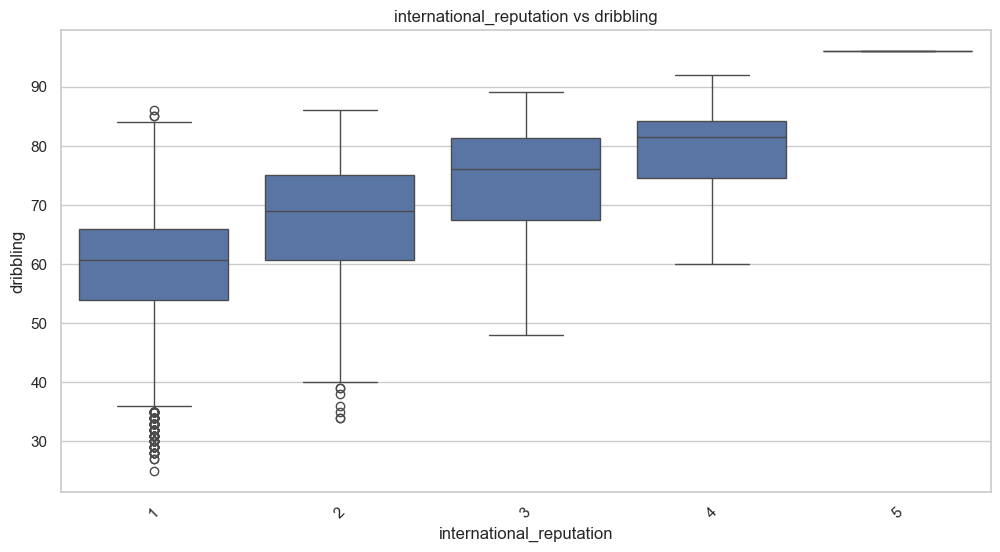

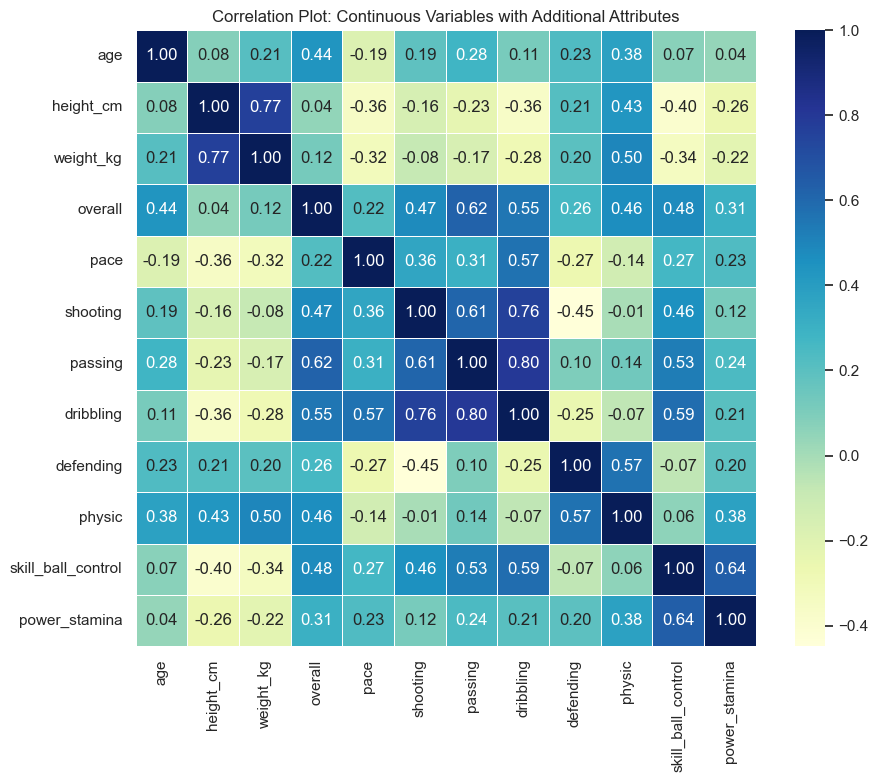

In [106]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
data = pd.read_csv('C:/Users/cw/Desktop/Cleaned_FIFA_Players_Data.csv')
sns.set(style="whitegrid")

# Scatter Plot which is Continuous vs Continuous 
# 1 Height vs Weight
plt.figure(figsize=(8, 6))
sns.scatterplot(data=data, x='height_cm', y='weight_kg', alpha=0.5)
plt.title('Scatter Plot: Height vs Weight')
plt.xlabel('Height (cm)')
plt.ylabel('Weight (kg)')
plt.show()

# 2 Power Stamina vs Physic
plt.figure(figsize=(8, 6))
sns.scatterplot(data=data, x='power_stamina', y='physic', alpha=0.5)
plt.title('Scatter Plot: Power Stamina vs Physic')
plt.xlabel('Power Stamina')
plt.ylabel('Physic')
plt.show()

#  Box Plot which is Discrete vs Continuous 
# 1 Nationality vs Pace
top_nationalities = data['nationality'].value_counts().index[:10]#top 10 for cleare plot
data_top_nationalities = data[data['nationality'].isin(top_nationalities)]
plt.figure(figsize=(12, 6))
sns.boxplot(data=data_top_nationalities, x='nationality', y='pace')
plt.xticks(rotation=45)
plt.title('Box Plot: Nationality vs Pace')
plt.xlabel('Nationality')
plt.ylabel('Pace')
plt.show()

#2 international repuation vs dribbling
plt.figure(figsize=(12, 6))
sns.boxplot(data=data_top_nationalities, x='international_reputation', y='dribbling')
plt.xticks(rotation=45)
plt.title('international_reputation vs dribbling')
plt.xlabel('international_reputation')
plt.ylabel('dribbling')
plt.show()

# Correlation Plot which is Continuous Variables along with Additional Attributes

continuous_columns = ['age', 'height_cm', 'weight_kg', 'overall', 'pace', 'shooting', 'passing', 
                      'dribbling', 'defending', 'physic', 'skill_ball_control', 'power_stamina']
corr_matrix = data[continuous_columns].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='YlGnBu', fmt='.2f', linewidths=0.5)
plt.title('Correlation Plot: Continuous Variables with Additional Attributes')
plt.show()

### The scatter plot shows a positive correlation between height and weight, with taller individuals generally weighing more. There is a strong cluster between 170-200 cm height and 60-100 kg weight.
### This scatter plot shows a positive correlation between Power Stamina and Physic, where higher stamina generally corresponds to higher physical ratings. There is a notable concentration of data points around stamina values of 40-80 and physic ratings of 60-80.
### This box plot compares Pace across players from different nationalities. Most nationalities have a similar median pace around 70, with Argentina and Germany having slightly higher pace ranges, while the Republic of Ireland has more variability and lower outliers.
### This box plot shows that players with higher international reputation generally have better *dribbling skills*. As reputation increases, dribbling scores improve, and the variation in those scores decreases
### This heatmap shows the correlation between different player attributes. Strong positive correlations can be seen between *shooting, **passing, and **dribbling, while weaker or negative correlations exist between attributes like **height* and *pace*.


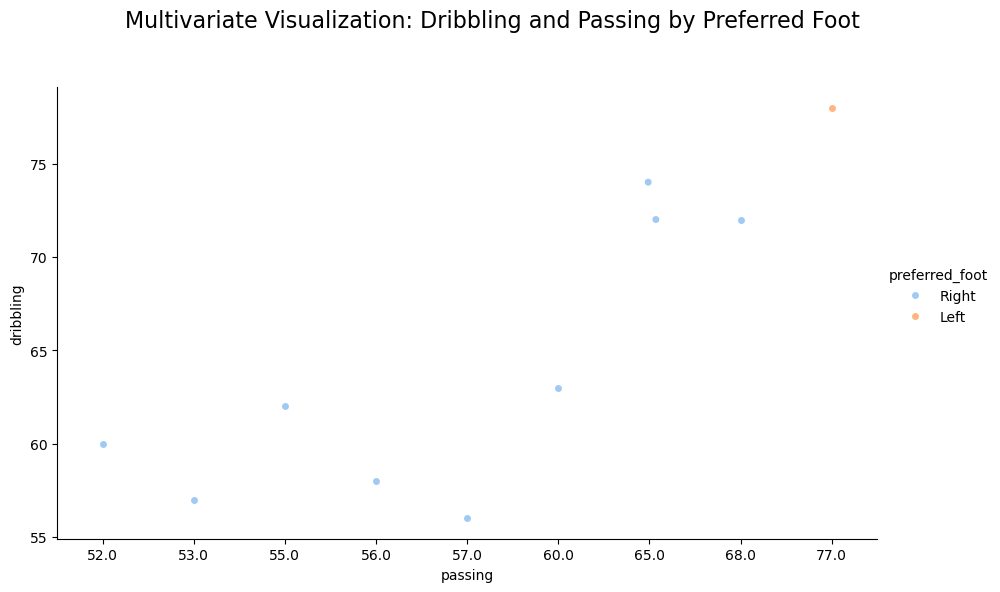

In [15]:
#part2.3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
data = pd.read_csv('C:/Users/cw/Desktop/Cleaned_FIFA_Players_Data.csv')

# Select subset of the dataset with more than two variables in order to sisplay a multivariate
subset_df = data[['dribbling', 'passing', 'preferred_foot']].dropna().sample(10)
# Using stripplot to avoid overlapping
sns.catplot(x='passing', y='dribbling', hue='preferred_foot', data=subset_df, kind='strip', height=6, aspect=1.5, palette='pastel', jitter=True)
plt.subplots_adjust(top=0.85)
plt.suptitle('Multivariate Visualization: Dribbling and Passing by Preferred Foot', fontsize=16)
plt.show()


### This catplot shows the relationship between dribbling and passing for players, separated by their preferred foot (right or left). The data points indicate that both left- and right-footed players have varying dribbling and passing abilities, with no clear clustering based on foot preference in this small sample.